  DATASET 1: YOUTH UNEMPLOYMENT & SKILLS GAP — CLEANING

[✓] Shape: 10 rows x 10 columns
[✓] Missing Values: 0
[✓] Cleaning & Feature Engineering complete.



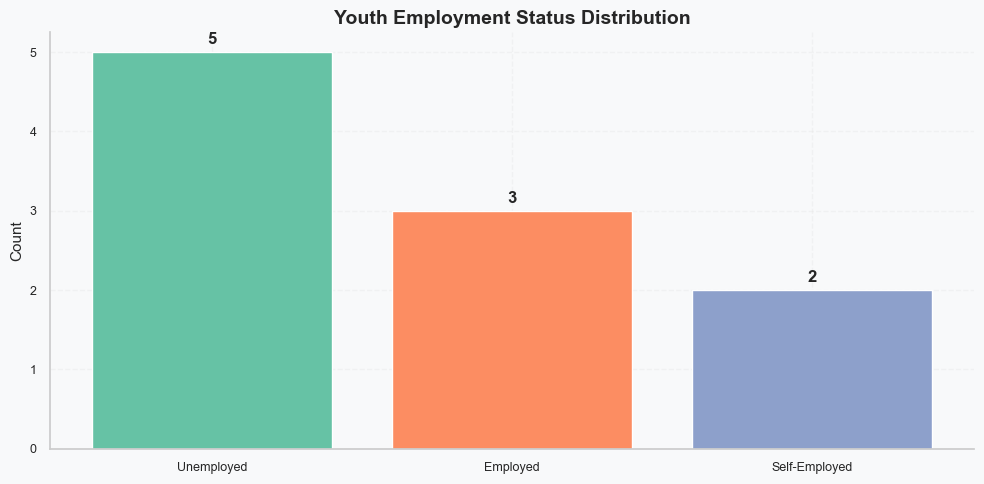

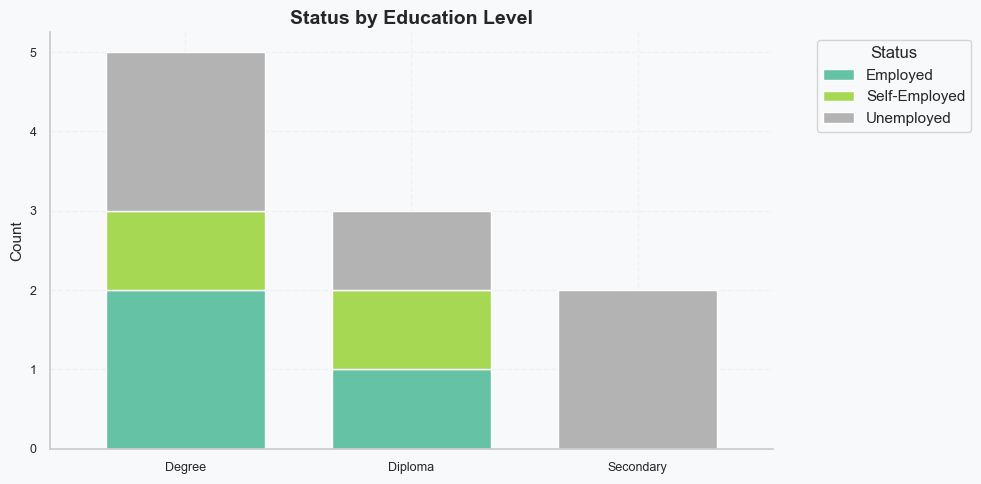

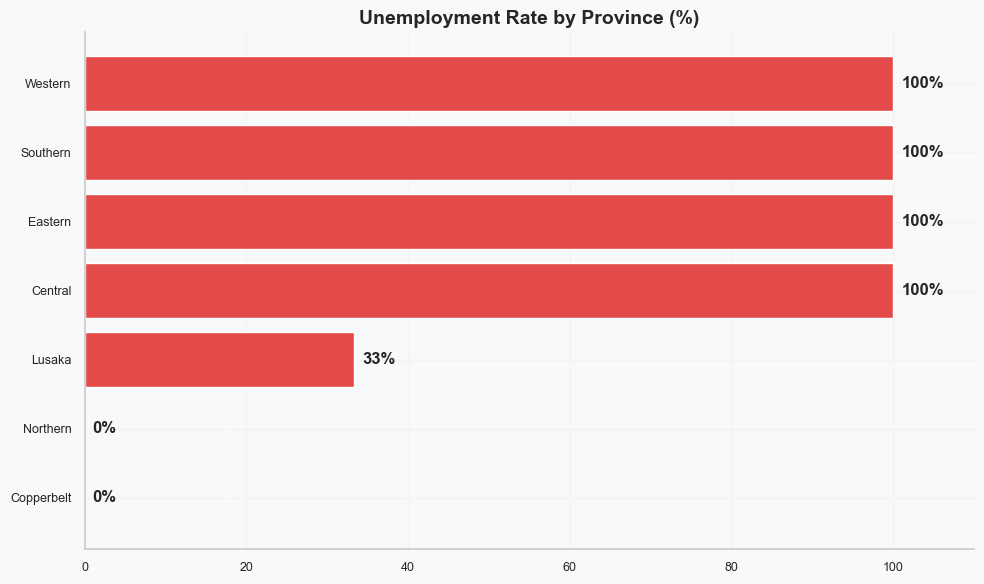

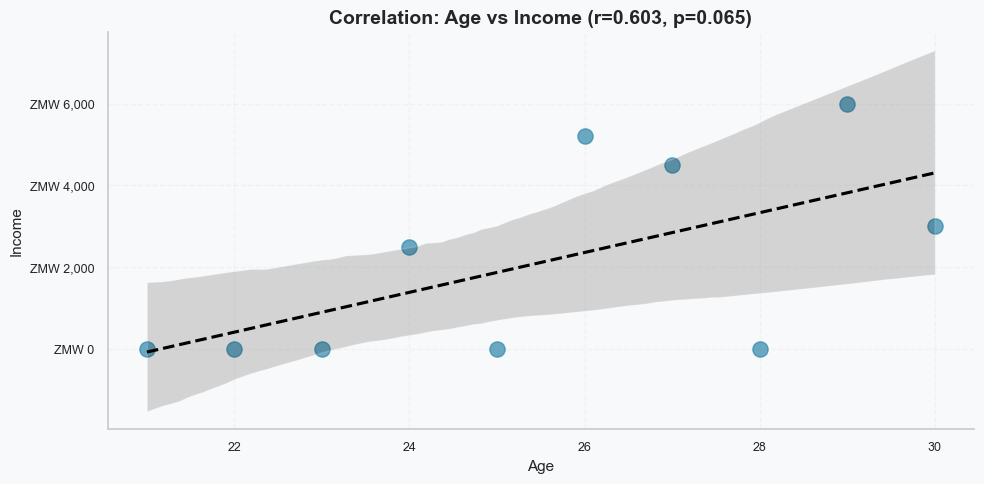

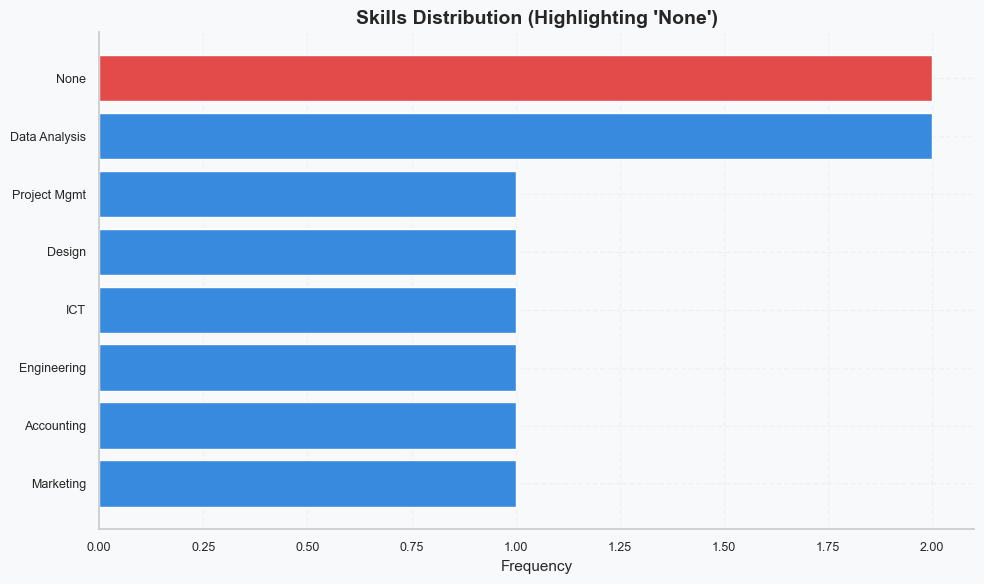


  FINAL INSIGHT SUMMARY
Total Sample Size      : 10
Overall Unemployment   : 50.0%
Critical Province      : Western
Age-Income Correlation : 0.603

[✓] All 51 charts saved to: \mnt\user-data\outputs
Analysis complete.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
import warnings
from pathlib import Path
from scipy.stats import pearsonr

# ──────────────────────────────────────────────────────────
# 1. GLOBAL STYLE CONFIGURATION 
# ──────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")

# Define paths and ensure output directory exists
OUTPUT_DIR = Path("/mnt/user-data/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Aesthetic constants
PALETTE  = "Set2"
BG_COLOR = "#F8F9FA"  # Light professional grey
GRID_CLR = "#E0E0E0"
ACCENT   = "#E24B4A"  # Primary color for unemployment focus

# Update Matplotlib global parameters for consistent styling
plt.rcParams.update({
    "figure.facecolor"  : BG_COLOR,
    "axes.facecolor"    : BG_COLOR,
    "axes.grid"         : True,
    "grid.color"        : GRID_CLR,
    "grid.linestyle"    : "--",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "sans-serif",
    "axes.titlesize"    : 14,
    "axes.labelsize"    : 11,
    "xtick.labelsize"   : 9,
    "ytick.labelsize"   : 9,
})

# ──────────────────────────────────────────────────────────
# 2. DATA LOADING & CLEANING SECTION
# ──────────────────────────────────────────────────────────
print("=" * 65)
print("  DATASET 1: YOUTH UNEMPLOYMENT & SKILLS GAP — CLEANING")
print("=" * 65)

# Raw Dataset
data = {
    "ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Age": [23, 27, 21, 30, 25, 29, 22, 26, 24, 28],
    "Province": ["Lusaka", "Copperbelt", "Eastern", "Lusaka", "Southern",
                 "Copperbelt", "Western", "Lusaka", "Northern", "Central"],
    "Education": ["Degree", "Diploma", "Secondary", "Degree", "Diploma",
                  "Degree", "Secondary", "Degree", "Diploma", "Degree"],
    "Status": ["Unemployed", "Employed", "Unemployed", "Self-Employed",
               "Unemployed", "Employed", "Unemployed", "Employed",
               "Self-Employed", "Unemployed"],
    "Income": [0, 4500, 0, 3000, 0, 6000, 0, 5200, 2500, 0],
    "Skills": ["Data Analysis", "Accounting", "None", "Marketing", "ICT",
               "Engineering", "None", "Data Analysis", "Design", "Project Mgmt"]
}

df = pd.DataFrame(data)

# --- CLEANING & FEATURE ENGINEERING ---
# Standardize string formatting
df["Province"]  = df["Province"].str.strip().str.title()
df["Education"] = df["Education"].str.strip().str.title()
df["Status"]    = df["Status"].str.strip().str.title()

# Engineering numeric indicators for analysis
df["Is_Unemployed"] = (df["Status"] == "Unemployed").astype(int)
df["Has_Skill"]     = df["Skills"].apply(lambda x: 0 if x == "None" else 1)
df["Income_Log"]    = np.log1p(df["Income"])  # Log transform to handle skewness

print(f"\n[✓] Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"[✓] Missing Values: {df.isnull().sum().sum()}")
print("[✓] Cleaning & Feature Engineering complete.\n")

# ──────────────────────────────────────────────────────────
# 3. VISUALISATIONS
# ──────────────────────────────────────────────────────────

# FIGURE 1: Employment Status Distribution
status_counts = df["Status"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(status_counts.index, status_counts.values, color=sns.color_palette(PALETTE), edgecolor="white")

# Add value labels on top
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
            f"{int(bar.get_height())}", ha="center", fontweight="bold")

ax.set_title("Youth Employment Status Distribution", fontweight="bold")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_employment_status.png", dpi=150)
plt.show()


# FIGURE 2: Education vs Status (Stacked Bar)
edu_status = pd.crosstab(df["Education"], df["Status"])
fig, ax = plt.subplots(figsize=(10, 5))
edu_status.plot(kind="bar", stacked=True, ax=ax, colormap="Set2", edgecolor="white", width=0.7)

ax.set_title("Status by Education Level", fontweight="bold")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=0)
ax.legend(title="Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_education_vs_status.png", dpi=150)
plt.show()


# FIGURE 3: Provincial Unemployment Rate (Horizontal Bar)
prov_unemp = (df.groupby("Province")["Is_Unemployed"].mean() * 100).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prov_unemp.index, prov_unemp.values, color=ACCENT, edgecolor="white")

# Add percentage labels to the end of bars
for bar in bars:
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f"{bar.get_width():.0f}%", va="center", fontweight="bold")

ax.set_title("Unemployment Rate by Province (%)", fontweight="bold")
ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_provincial_unemployment.png", dpi=150)
plt.show()


# FIGURE 4: Age vs Income (Scatter + Regression)
fig, ax = plt.subplots(figsize=(10, 5))
sns.regplot(data=df, x="Age", y="Income", scatter_kws={'s':120, 'alpha':0.7}, 
            line_kws={'color': 'black', 'linestyle': '--'}, color="#2E86AB", ax=ax)

# Add correlation info to title
r, p = pearsonr(df["Age"], df["Income"])
ax.set_title(f"Correlation: Age vs Income (r={r:.3f}, p={p:.3f})", fontweight="bold")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"ZMW {int(x):,}"))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_age_income_regression.png", dpi=150)
plt.show()


# FIGURE 5: Skills Frequency (Filtered)
skill_counts = df["Skills"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
colors = [ACCENT if s == "None" else "#378ADD" for s in skill_counts.index]
ax.barh(skill_counts.index, skill_counts.values, color=colors, edgecolor="white")

ax.set_title("Skills Distribution (Highlighting 'None')", fontweight="bold")
ax.set_xlabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_skills_distribution.png", dpi=150)
plt.show()

# ──────────────────────────────────────────────────────────
# 4. STATISTICAL SUMMARY
# ──────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  FINAL INSIGHT SUMMARY")
print("=" * 55)

unemp_rate = df["Is_Unemployed"].mean() * 100
total_youth = len(df)
high_unemp_prov = prov_unemp.index[-1]

print(f"Total Sample Size      : {total_youth}")
print(f"Overall Unemployment   : {unemp_rate:.1f}%")
print(f"Critical Province      : {high_unemp_prov}")
print(f"Age-Income Correlation : {r:.3f}")

print(f"\n[✓] All {len(list(OUTPUT_DIR.glob('*.png')))} charts saved to: {OUTPUT_DIR}")
print("Analysis complete.")